<a href="https://colab.research.google.com/github/Pranaytejak/new/blob/main/skip_gram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies
!pip install gensim matplotlib scikit-learn -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.3 MB/s eta 0:00:00
✅ Libraries loaded!


In [2]:
# REAL WORLD SCENARIO:
# You work at an e-commerce company (like Amazon/Flipkart).
# You have thousands of product reviews.
# Goal: Train Skip-gram so the model understands
#        product relationships from customer language.

ecommerce_reviews = [
    # Electronics
    "the laptop has great battery life and fast processor",
    "this phone has an amazing camera and bright screen",
    "the headphones have excellent sound quality and noise cancellation",
    "the charger is fast and the cable is durable",
    "the keyboard is mechanical and has rgb lighting",
    "this monitor has high resolution and wide color gamut",
    "the speaker is loud with deep bass and clear treble",
    "the tablet is lightweight with long battery and sharp display",

    # Fashion
    "the shirt is soft comfortable and good quality fabric",
    "these shoes are comfortable lightweight and durable",
    "the jacket keeps you warm in cold weather",
    "the dress is elegant stylish and fits perfectly",
    "the bag is spacious lightweight and has good zippers",

    # Kitchen
    "the blender is powerful quiet and easy to clean",
    "the knife is sharp balanced and comfortable to hold",
    "the pan is non-stick heats evenly and easy to wash",
    "the coffee maker brews strong hot coffee quickly",
    "the rice cooker is automatic easy and cooks perfectly",

    # Sports
    "the yoga mat is thick non-slip and comfortable",
    "the running shoes have good grip and cushioning",
    "the water bottle is leak-proof and keeps water cold",
    "the dumbbell set is solid heavy and good for workouts",
    "the bicycle helmet is light strong and fits well",
]

# Tokenize
tokenized = [sentence.lower().split() for sentence in ecommerce_reviews]
print(f"✅ Dataset: {len(tokenized)} product reviews")
print(f"Sample: {tokenized[0]}")

✅ Dataset: 23 product reviews
Sample: ['the', 'laptop', 'has', 'great', 'battery', 'life', 'and', 'fast', 'processor']


In [3]:
# ─────────────────────────────────────────────────────
#  SKIP-GRAM INTUITION
# ─────────────────────────────────────────────────────
#
#  Given a CENTER word → Predict its SURROUNDING words
#
#  Sentence: "the phone has an amazing camera"
#                              ↑
#                         center word
#
#  Window size = 2:
#  Context words = ["phone", "has", "an", "camera"]  ← predict these
#
#  Unlike CBOW (which goes context → center),
#  Skip-gram goes:  center → context
#
#  Why Skip-gram?
#  ✔ Better for rare words
#  ✔ Better with small datasets
#  ✔ Captures fine-grained semantic relationships
# ─────────────────────────────────────────────────────

def show_skipgram_pairs(sentence, window=2):
    words = sentence.lower().split()
    print(f"\nSentence : '{sentence}'")
    print(f"Window   : {window}\n")
    print(f"{'Center Word':<15} → Context Words")
    print("-" * 40)
    for i, center in enumerate(words):
        context = []
        for j in range(max(0, i-window), min(len(words), i+window+1)):
            if j != i:
                context.append(words[j])
        print(f"  {center:<13} → {context}")

show_skipgram_pairs("the phone has an amazing camera and bright screen")


Sentence : 'the phone has an amazing camera and bright screen'
Window   : 2

Center Word     → Context Words
----------------------------------------
  the           → ['phone', 'has']
  phone         → ['the', 'has', 'an']
  has           → ['the', 'phone', 'an', 'amazing']
  an            → ['phone', 'has', 'amazing', 'camera']
  amazing       → ['has', 'an', 'camera', 'and']
  camera        → ['an', 'amazing', 'and', 'bright']
  and           → ['amazing', 'camera', 'bright', 'screen']
  bright        → ['camera', 'and', 'screen']
  screen        → ['and', 'bright']


In [4]:
from gensim.models import Word2Vec

# Train Skip-gram (sg=1 means Skip-gram, sg=0 means CBOW)
model = Word2Vec(
    sentences=tokenized,
    vector_size=50,      # embedding dimensions
    window=3,            # context window size
    min_count=1,         # include all words
    sg=1,                # ← Skip-gram!
    epochs=200,          # training iterations
    seed=42
)

print("✅ Skip-gram model trained!")
print(f"Vocabulary size : {len(model.wv.key_to_index)} words")
print(f"Embedding size  : {model.wv.vector_size} dimensions")
print(f"\nSample vector for 'camera' (first 8 dims):")
print(np.round(model.wv['camera'][:8], 4))

✅ Skip-gram model trained!
Vocabulary size : 116 words
Embedding size  : 50 dimensions

Sample vector for 'camera' (first 8 dims):
[ 0.1028 -0.1429 -0.0984  0.2136 -0.183   0.1062 -0.2104  0.2015]


In [5]:
print("=" * 55)
print("   REAL-WORLD USE CASE: Product Recommendation Engine")
print("=" * 55)

queries = [
    ("camera",    "📷 If customer searches 'camera', also show:"),
    ("battery",   "🔋 Related to 'battery':"),
    ("comfortable","😊 Related to 'comfortable':"),
    ("sharp",     "🔪 Related to 'sharp':"),
    ("fast",      "⚡ Related to 'fast':"),
]

for word, label in queries:
    similar = model.wv.most_similar(word, topn=4)
    print(f"\n{label}")
    for sim_word, score in similar:
        bar = "█" * int(score * 20)
        print(f"   {sim_word:<15} {score:.3f}  {bar}")

   REAL-WORLD USE CASE: Product Recommendation Engine

📷 If customer searches 'camera', also show:
   amazing         0.996  ███████████████████
   screen          0.996  ███████████████████
   bright          0.996  ███████████████████
   phone           0.995  ███████████████████

🔋 Related to 'battery':
   fast            0.992  ███████████████████
   great           0.992  ███████████████████
   has             0.991  ███████████████████
   life            0.991  ███████████████████

😊 Related to 'comfortable':
   knife           0.993  ███████████████████
   and             0.993  ███████████████████
   fabric          0.992  ███████████████████
   durable         0.992  ███████████████████

🔪 Related to 'sharp':
   knife           0.992  ███████████████████
   balanced        0.991  ███████████████████
   lightweight     0.991  ███████████████████
   and             0.991  ███████████████████

⚡ Related to 'fast':
   life            0.994  ███████████████████
   processor       0

In [6]:
print("=" * 55)
print("   WORD ARITHMETIC — Semantic Relationships")
print("=" * 55)

# phone + camera - screen ≈ ?
result = model.wv.most_similar(
    positive=['phone', 'camera'],
    negative=['screen'],
    topn=3
)
print("\n📐 phone + camera - screen = ?")
for word, score in result:
    print(f"   → {word} ({score:.3f})")

# laptop + battery - processor ≈ ?
result2 = model.wv.most_similar(
    positive=['laptop', 'battery'],
    negative=['processor'],
    topn=3
)
print("\n📐 laptop + battery - processor = ?")
for word, score in result2:
    print(f"   → {word} ({score:.3f})")

   WORD ARITHMETIC — Semantic Relationships

📐 phone + camera - screen = ?
   → amazing (0.992)
   → bright (0.991)
   → an (0.991)

📐 laptop + battery - processor = ?
   → zippers (0.989)
   → has (0.989)
   → these (0.988)


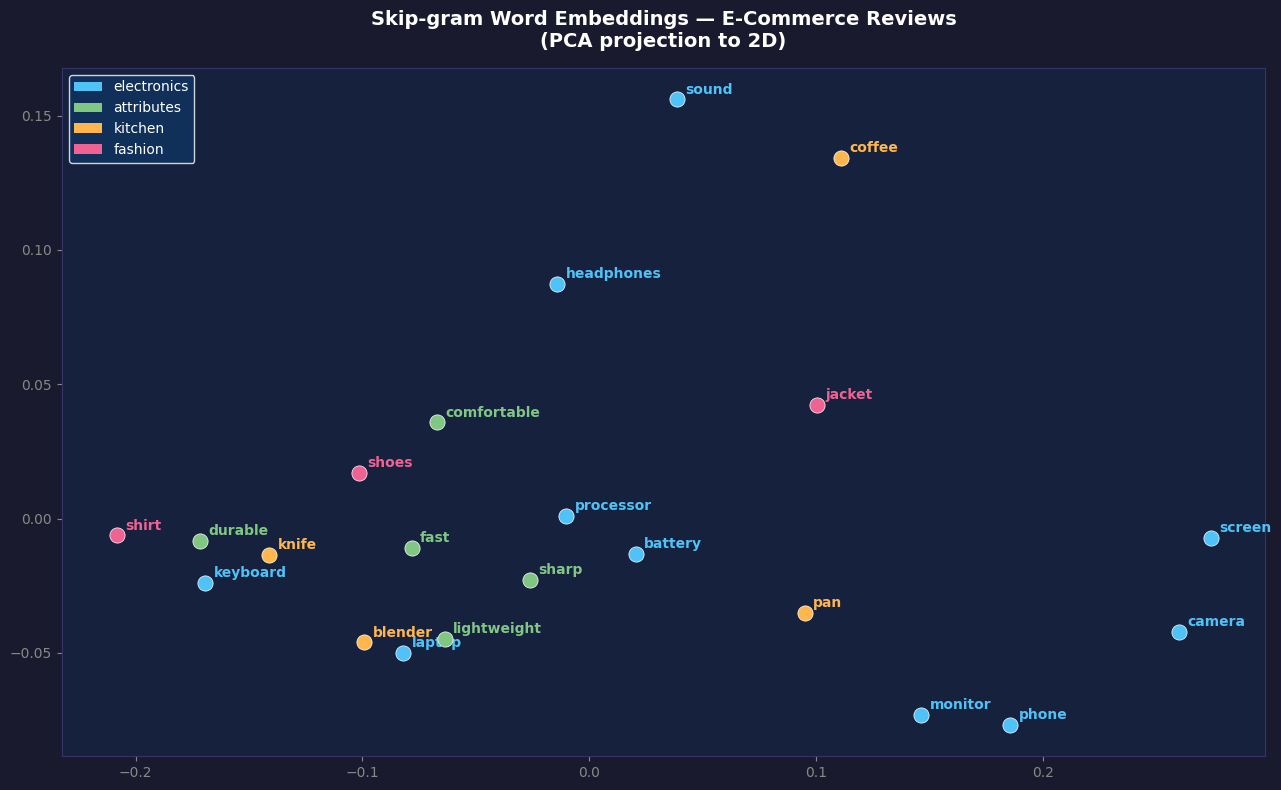

✅ Saved: skipgram_clusters.png


In [7]:
# Select meaningful product-related words
focus_words = [
    'camera', 'screen', 'battery', 'processor', 'phone', 'laptop',
    'sound', 'headphones', 'keyboard', 'monitor',
    'comfortable', 'lightweight', 'durable', 'sharp', 'fast',
    'coffee', 'blender', 'knife', 'pan',
    'shoes', 'jacket', 'shirt'
]

# Filter words that exist in vocabulary
focus_words = [w for w in focus_words if w in model.wv.key_to_index]

vectors = np.array([model.wv[w] for w in focus_words])

# Reduce to 2D with PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Color categories
colors = {
    'electronics': ('#4FC3F7', ['camera', 'screen', 'battery', 'processor', 'phone', 'laptop', 'sound', 'headphones', 'keyboard', 'monitor']),
    'attributes':  ('#81C784', ['comfortable', 'lightweight', 'durable', 'sharp', 'fast']),
    'kitchen':     ('#FFB74D', ['coffee', 'blender', 'knife', 'pan']),
    'fashion':     ('#F06292', ['shoes', 'jacket', 'shirt']),
}

word_colors = {}
for cat, (color, words) in colors.items():
    for w in words:
        word_colors[w] = color

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

for i, word in enumerate(focus_words):
    c = word_colors.get(word, '#ffffff')
    ax.scatter(coords[i, 0], coords[i, 1], color=c, s=120, zorder=3, edgecolors='white', linewidths=0.5)
    ax.annotate(word, (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=10, color=c, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, (c, _) in colors.items()]
ax.legend(handles=legend_elements, loc='upper left',
          facecolor='#0f3460', edgecolor='white', labelcolor='white', fontsize=10)

ax.set_title("Skip-gram Word Embeddings — E-Commerce Reviews\n(PCA projection to 2D)",
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#888888')
for spine in ax.spines.values():
    spine.set_edgecolor('#333366')

plt.tight_layout()
plt.savefig('skipgram_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: skipgram_clusters.png")

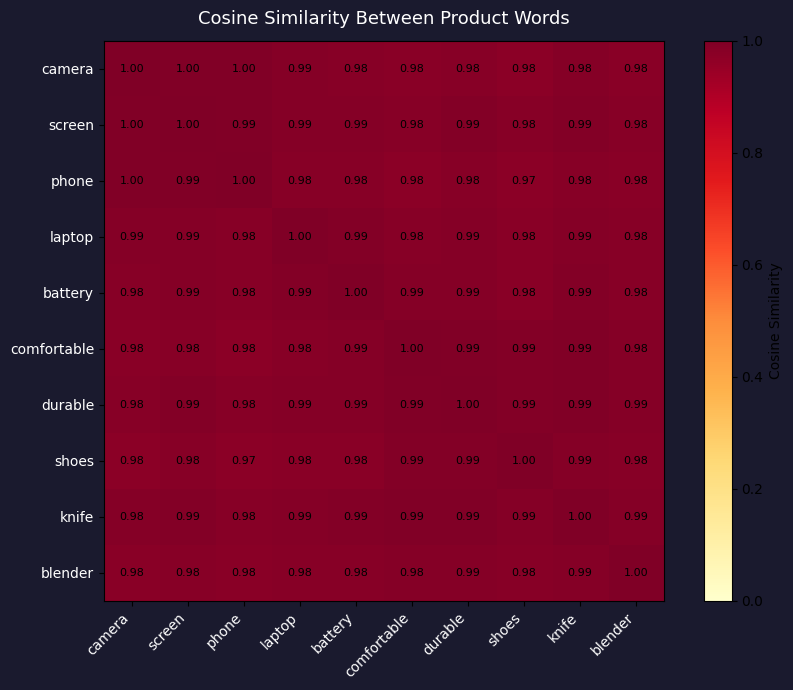

In [9]:
words_heatmap = ['camera', 'screen', 'phone', 'laptop', 'battery',
                 'comfortable', 'durable', 'shoes', 'knife', 'blender']
words_heatmap = [w for w in words_heatmap if w in model.wv.key_to_index]

vecs = np.array([model.wv[w] for w in words_heatmap])
sim_matrix = cosine_similarity(vecs)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')

ax.set_xticks(range(len(words_heatmap)))
ax.set_yticks(range(len(words_heatmap)))
ax.set_xticklabels(words_heatmap, rotation=45, ha='right', color='white')
ax.set_yticklabels(words_heatmap, color='white')

for i in range(len(words_heatmap)):
    for j in range(len(words_heatmap)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                fontsize=8, color='black' if sim_matrix[i,j] > 0.5 else 'white')

ax.set_title("Cosine Similarity Between Product Words", color='white', fontsize=13, pad=12)
plt.tight_layout()
plt.show()